# Notebook 01 - PoseFormerV2 Setup Test

Objectives of this notebook:

1. Test the Python, PyTorch, and CUDA environment.

2. Test the project path, checkpoints, and data.

3. Import the PoseFormerV2 inferencer.

4. Run PoseFormerV2 using simulated 2D keypoints as input.

5. Check if the 3D skeleton output is the correct shape `(17, 3)`.

In [1]:
from pathlib import Path
import sys
import os

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]

PHASE2_DIR = PROJECT_ROOT / "phase2_3d_upgrade"
INFERENCE_DIR = PHASE2_DIR / "inference"
CHECKPOINT_DIR = PHASE2_DIR / "checkpoints"
OUTPUT_DIR = PHASE2_DIR / "outputs"

sys.path.append(str(PHASE2_DIR))
sys.path.append(str(INFERENCE_DIR))

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Phase 2 dir:", PHASE2_DIR)
print("Inference dir:", INFERENCE_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)

Notebook dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\notebooks
Project root: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH
Phase 2 dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade
Inference dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\inference
Checkpoint dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\checkpoints


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current CUDA device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Python executable: c:\Users\ASUS\anaconda3\envs\nckh_3dpose\python.exe
PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True
CUDA device count: 1
Current CUDA device: 0
GPU name: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
checkpoint_27 = CHECKPOINT_DIR / "1_3_27_48.7.bin"
checkpoint_243 = CHECKPOINT_DIR / "27_243_45.2.bin"

data_2d_dir = PROJECT_ROOT / "data" / "2_extracted_2d"
data_3d_dir = PROJECT_ROOT / "data" / "3_extracted_3d"
data_3d_norm_dir = PROJECT_ROOT / "data" / "4_normalized_3d"

paths_to_check = {
    "checkpoint_27": checkpoint_27,
    "checkpoint_243": checkpoint_243,
    "data_2d_dir": data_2d_dir,
    "data_3d_dir": data_3d_dir,
    "data_3d_norm_dir": data_3d_norm_dir,
}

for name, path in paths_to_check.items():
    print(f"{name}: {path}")
    print("Exists:", path.exists())
    print("-" * 80)

checkpoint_27: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\checkpoints\1_3_27_48.7.bin
Exists: True
--------------------------------------------------------------------------------
checkpoint_243: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\checkpoints\27_243_45.2.bin
Exists: True
--------------------------------------------------------------------------------
data_2d_dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\2_extracted_2d
Exists: True
--------------------------------------------------------------------------------
data_3d_dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\3_extracted_3d
Exists: True
--------------------------------------------------------------------------------
data_3d_norm_dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\4_normalized_3d
Exists: True
--------------------------------------------------------------------------------


In [4]:
import inspect

from inference.infer_3d_pose import PoseFormerV2Inferencer

print("PoseFormerV2Inferencer imported successfully.")
print("Constructor signature:")
print(inspect.signature(PoseFormerV2Inferencer))

c:\Users\ASUS\anaconda3\envs\nckh_3dpose\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PoseFormerV2Inferencer imported successfully.
Constructor signature:
(checkpoint_path=None, sequence_length=27, frame_kept=1, coeff_kept=3, device=None)


c:\Users\ASUS\anaconda3\envs\nckh_3dpose\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [5]:
def create_poseformer_inferencer(checkpoint_path):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    try:
        return PoseFormerV2Inferencer(
            checkpoint_path=str(checkpoint_path),
            device=device
        )
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(
            ckpt_path=str(checkpoint_path),
            device=device
        )
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(
            model_path=str(checkpoint_path),
            device=device
        )
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(str(checkpoint_path), device)
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(str(checkpoint_path))
    except TypeError:
        pass

    return PoseFormerV2Inferencer()


inferencer = create_poseformer_inferencer(checkpoint_27)

print("Inferencer created successfully.")
print("Inferencer type:", type(inferencer))

Loaded PoseFormerV2 checkpoint:
  Path: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\checkpoints\1_3_27_48.7.bin
  Device: cuda
  Sequence length: 27
  Frame kept: 1
  Coeff kept: 3
Inferencer created successfully.
Inferencer type: <class 'inference.infer_3d_pose.PoseFormerV2Inferencer'>


In [6]:
def create_fake_coco_keypoints(frame_idx=0):
    base = np.array([
        [320, 120],  # 0 nose / pelvis depending on adapter
        [300, 140],
        [340, 140],
        [285, 160],
        [355, 160],
        [280, 210],
        [360, 210],
        [260, 280],
        [380, 280],
        [250, 350],
        [390, 350],
        [300, 360],
        [340, 360],
        [290, 450],
        [350, 450],
        [285, 540],
        [355, 540],
    ], dtype=np.float32)

    movement = np.array([frame_idx * 0.5, np.sin(frame_idx / 5) * 3], dtype=np.float32)

    noise = np.random.normal(0, 1.5, base.shape).astype(np.float32)

    return base + movement + noise


fake_kpts = create_fake_coco_keypoints(0)

print("Fake 2D keypoints shape:", fake_kpts.shape)
print(fake_kpts[:5])

Fake 2D keypoints shape: (17, 2)
[[320.48962  116.869194]
 [301.45203  138.75487 ]
 [339.9599   142.87918 ]
 [284.79117  158.04524 ]
 [353.40195  159.5663  ]]


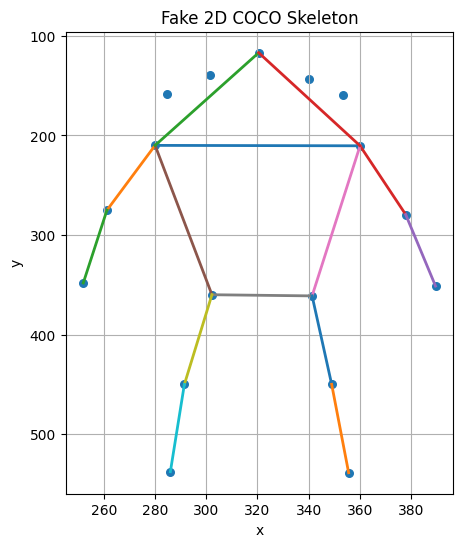

In [7]:
COCO_EDGES = [
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (0, 5), (0, 6)
]

plt.figure(figsize=(5, 6))

for a, b in COCO_EDGES:
    plt.plot(
        [fake_kpts[a, 0], fake_kpts[b, 0]],
        [fake_kpts[a, 1], fake_kpts[b, 1]],
        linewidth=2
    )

plt.scatter(fake_kpts[:, 0], fake_kpts[:, 1], s=30)
plt.gca().invert_yaxis()
plt.title("Fake 2D COCO Skeleton")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [8]:
outputs = []

for i in range(35):
    kpts_2d = create_fake_coco_keypoints(i)

    try:
        pred_3d = inferencer.add_and_predict(kpts_2d)
    except AttributeError:
        raise AttributeError(
            "Inferencer does not have add_and_predict(). "
            "Check phase2_3d_upgrade/inference/infer_3d_pose.py"
        )

    outputs.append(pred_3d)

valid_outputs = [o for o in outputs if o is not None]

print("Total calls:", len(outputs))
print("Valid 3D outputs:", len(valid_outputs))

if valid_outputs:
    pose3d = valid_outputs[-1]
    print("Last 3D output type:", type(pose3d))
    print("Last 3D output shape:", np.asarray(pose3d).shape)
    print(np.asarray(pose3d)[:5])
else:
    print("No 3D output generated yet. PoseFormerV2 may need more valid frames.")

Total calls: 35
Valid 3D outputs: 9
Last 3D output type: <class 'numpy.ndarray'>
Last 3D output shape: (17, 3)
[[-4.9657002e-04  4.1233841e-04 -2.0544976e-06]
 [ 9.0121776e-02  9.0311123e-03 -2.9894350e-02]
 [ 1.0753343e-01  3.2299596e-01  2.0565709e-01]
 [ 1.1236943e-01  6.5320188e-01  2.8863865e-01]
 [-8.8908553e-02 -9.2735859e-03  2.9462766e-02]]


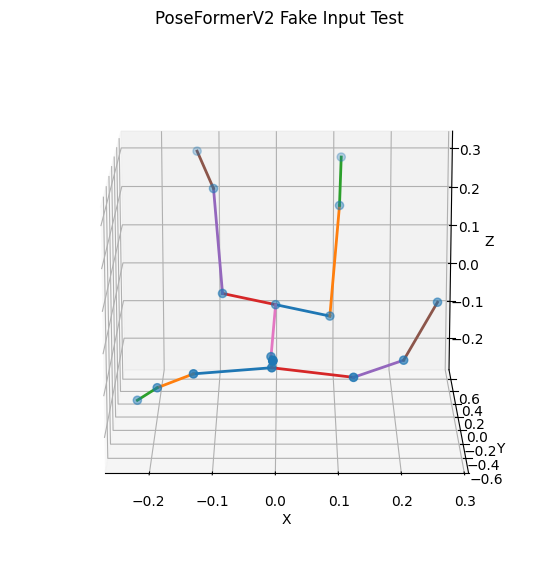

In [9]:
def plot_3d_pose(pose3d, title="Predicted 3D Pose"):
    pose3d = np.asarray(pose3d, dtype=np.float32)

    if pose3d.shape != (17, 3):
        raise ValueError(f"Expected pose shape (17, 3), got {pose3d.shape}")

    edges = [
        (0, 1), (1, 2), (2, 3),
        (0, 4), (4, 5), (5, 6),
        (0, 7), (7, 8), (8, 9), (9, 10),
        (8, 11), (11, 12), (12, 13),
        (8, 14), (14, 15), (15, 16)
    ]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    xs = pose3d[:, 0]
    ys = pose3d[:, 1]
    zs = pose3d[:, 2]

    ax.scatter(xs, ys, zs, s=35)

    for a, b in edges:
        ax.plot(
            [xs[a], xs[b]],
            [ys[a], ys[b]],
            [zs[a], zs[b]],
            linewidth=2
        )

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=15, azim=-90)

    plt.show()


if valid_outputs:
    plot_3d_pose(valid_outputs[-1], "PoseFormerV2 Fake Input Test")

In [10]:
if valid_outputs and np.asarray(valid_outputs[-1]).shape == (17, 3):
    print("Setup test passed.")
    print("PoseFormerV2 can generate 3D pose with shape (17, 3).")
else:
    print("Setup test not fully passed.")
    print("Check inferencer, checkpoint, or input format.")

Setup test passed.
PoseFormerV2 can generate 3D pose with shape (17, 3).
